In [2]:
import tensorflow as tf
import os

2026-06-27 06:00:52.744269: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782540053.101204      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782540053.210309      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782540054.099235      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782540054.099268      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782540054.099271      58 computation_placer.cc:177] computation placer alr

**LOADING THE DATA AND SPLITTING IT**

In [3]:
data_dir = '/kaggle/input/datasets/prananddesai/eurosat/2750'

#creating training dataset
print("Loading training data...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2, #20% of the data will be used for test and cross-validation
    subset="training", #80% reserved for training the model
    seed=837, #required to prevent data overlap
    image_size=(64, 64)
)

#creating the test and cv dataset
print("Loading test/cv data...")
test_cv_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2, #20% of the data will be used for test and cross-validation
    subset="validation", #20% reserved for testing and cross-validation
    seed=837, #required to prevent data overlap
    image_size=(64, 64)
)

batches_num = tf.data.experimental.cardinality(test_cv_ds)

test_ds = test_cv_ds.take(batches_num // 2)
cv_ds = test_cv_ds.skip(batches_num // 2)

#tf automatically figures out the best background loading speed
AUTOTUNE = tf.data.AUTOTUNE

#adding buffering to your datasets
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
cv_ds = cv_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("\nFinal Dataset Splits:")
print(f"Training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Validation batches: {tf.data.experimental.cardinality(cv_ds)}")
print(f"Test batches: {tf.data.experimental.cardinality(test_ds)}")

Loading training data...
Found 27000 files belonging to 10 classes.
Using 21600 files for training.


I0000 00:00:1782540098.057408      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782540098.063531      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Loading test/cv data...
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.

Final Dataset Splits:
Training batches: 675
Validation batches: 85
Test batches: 84


**APPLYING DATA TRANSFORMATIONS AND BUILDING THE MODEL**

In [4]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications import ResNet50

#loading the pre trained ResNet50 model
base_model = ResNet50(
    include_top=False,#do not include the top output layer
    weights='imagenet',#load the pretrained weights
    input_shape=(224, 224, 3),
    pooling = 'avg'
)
#freezing the layers
base_model.trainable = False

#creating the model
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(64, 64, 3)),

    tf.keras.layers.Resizing(224, 224),

    tf.keras.layers.RandomFlip("horizontal_and_vertical"),

    tf.keras.layers.Lambda(preprocess_input),

    base_model,
    tf.keras.layers.Dense(10, activation='linear')
])

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

**TRAINING THE MODEL**

In [5]:
model.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

epochs = 10

history = model.fit(
    train_ds,                 
    validation_data=cv_ds,
    epochs=epochs
)

Epoch 1/10


I0000 00:00:1782540115.277553     201 service.cc:152] XLA service 0x79d7f0002e20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782540115.277587     201 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782540115.277594     201 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782540117.149378     201 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/675 ━━━━━━━━━━━━━━━━━━━━ 51s 77ms/step - accuracy: 0.1406 - loss: 2.6684   

I0000 00:00:1782540122.804080     201 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


675/675 ━━━━━━━━━━━━━━━━━━━━ 94s 119ms/step - accuracy: 0.9225 - loss: 0.2490 - val_accuracy: 0.9436 - val_loss: 0.1605
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 66s 98ms/step - accuracy: 0.9607 - loss: 0.1155 - val_accuracy: 0.9499 - val_loss: 0.1430
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 65s 96ms/step - accuracy: 0.9691 - loss: 0.0920 - val_accuracy: 0.9524 - val_loss: 0.1385
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 64s 95ms/step - accuracy: 0.9758 - loss: 0.0730 - val_accuracy: 0.9576 - val_loss: 0.1281
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 65s 96ms/step - accuracy: 0.9780 - loss: 0.0660 - val_accuracy: 0.9569 - val_loss: 0.1359
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 64s 95ms/step - accuracy: 0.9799 - loss: 0.0590 - val_accuracy: 0.9554 - val_loss: 0.1346
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 64s 95ms/step - accuracy: 0.9824 - loss: 0.0530 - val_accuracy: 0.9572 - val_loss: 0.1225
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 65s 96ms/step - accuracy: 0.9845 - loss: 0.0471 - val_accura

**FINE TUNING**

In [6]:
base_model.trainable = True

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization): #freezing the batchnormalization layers
        layer.trainable = False

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,   
    restore_best_weights=True  
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

fine_tune_epochs = 15 

print("Starting fine-tuning phase...")

history_fine = model.fit(
    train_ds,                      
    validation_data=cv_ds,         
    epochs=fine_tune_epochs,
    callbacks=[early_stopping] 
)

model.save('/kaggle/working/eurosat_model.keras')

print("Model saved successfully!")

Starting fine-tuning phase...
Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 235s 297ms/step - accuracy: 0.9792 - loss: 0.0606 - val_accuracy: 0.9650 - val_loss: 0.1103
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 195s 288ms/step - accuracy: 0.9862 - loss: 0.0395 - val_accuracy: 0.9709 - val_loss: 0.1010
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 195s 289ms/step - accuracy: 0.9896 - loss: 0.0290 - val_accuracy: 0.9653 - val_loss: 0.0947
Epoch 4/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 193s 287ms/step - accuracy: 0.9938 - loss: 0.0211 - val_accuracy: 0.9742 - val_loss: 0.0887
Epoch 5/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 194s 288ms/step - accuracy: 0.9932 - loss: 0.0196 - val_accuracy: 0.9698 - val_loss: 0.0969
Epoch 6/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 194s 287ms/step - accuracy: 0.9933 - loss: 0.0189 - val_accuracy: 0.9790 - val_loss: 0.0782
Epoch 7/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 193s 286ms/step - accuracy: 0.9955 - loss: 0.0141 - val_accuracy: 0.9735 - val_loss: 0.0940
Epoch 8/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 194s 2

**EVALUATION**

Evaluating model on the test dataset...

Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.94      0.96      0.95       298
              Forest       0.99      1.00      0.99       318
HerbaceousVegetation       0.98      0.97      0.97       292
             Highway       0.99      0.98      0.99       238
          Industrial       0.98      1.00      0.99       243
             Pasture       0.96      0.93      0.95       197
       PermanentCrop       0.97      0.95      0.96       241
         Residential       1.00      0.99      1.00       299
               River       0.98      0.98      0.98       243
             SeaLake       0.98      1.00      0.99       319

            accuracy                           0.98      2688
           macro avg       0.98      0.98      0.98      2688
        weighted avg       0.98      0.98      0.98      2688



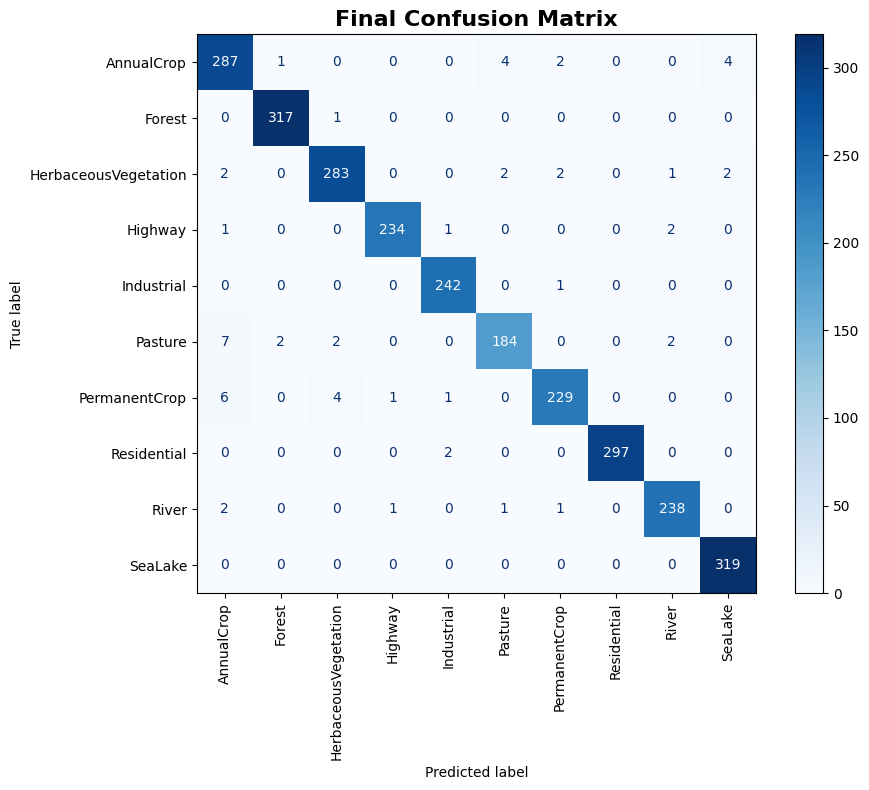

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Evaluating model on the test dataset...")

true_labels = []
predicted_labels = []

for images, labels in test_ds:
    true_labels.extend(labels.numpy())
    
    predictions = model.predict(images, verbose=0)
    
    #extracting the highest probability guess
    predicted_classes = np.argmax(predictions, axis=1)
    predicted_labels.extend(predicted_classes)

class_names = [
    'AnnualCrop', 'Forest', 'HerbaceousVegetation', 
    'Highway', 'Industrial', 'Pasture', 
    'PermanentCrop', 'Residential', 'River', 'SeaLake'
]

#printing the classification report
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

#generating confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

#setting up plot size
fig, ax = plt.subplots(figsize=(10, 8))

#displaying the matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plot it, attaching it to our specific figure size and rotating the x-axis labels so they don't overlap
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')

plt.title('Final Confusion Matrix', fontsize=16, weight='bold')
plt.tight_layout() # Ensures the rotated labels aren't cut off when saving the image
plt.savefig('confusion_matrix.png')
plt.show()

**INFERENCE**

In [9]:
#!apt-get install -y libopenjp2-7 libopenjp2-tools
#!pip install Pillow --upgrade

import numpy as np
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from PIL import Image

base_path = '/kaggle/input/datasets/prananddesai/petn-deforestation-data/Maya_Forest_Deforestation'

IMG_2018 = f"{base_path}/T15QYV_20180108T163639_TCI_10m.jp2"   # Before
IMG_2026 = f"{base_path}/T15QYV_20260423T163711_TCI_10m.jp2"   # After

PATCH_SIZE = 64      #match EuroSAT training size
BATCH_SIZE = 64      


CLASS_NAMES = [
    'AnnualCrop', 'Forest', 'HerbaceousVegetation',
    'Highway', 'Industrial', 'Pasture',
    'PermanentCrop', 'Residential', 'River', 'SeaLake'
]

#colours for the land cover map
CLASS_COLORS = {
    'AnnualCrop':           '#f4d03f',   # Yellow
    'Forest':               '#1a5c1a',   # Dark green
    'HerbaceousVegetation': '#82e07a',   # Light green
    'Highway':              '#808080',   # Grey
    'Industrial':           '#c0392b',   # Red
    'Pasture':              '#a9cce3',   # Light blue
    'PermanentCrop':        '#d35400',   # Orange
    'Residential':          '#884ea0',   # Purple
    'River':                '#2980b9',   # Blue
    'SeaLake':              '#1a5276',   # Dark blue
}

YEAR_LABELS = {
    IMG_2018: "2018 (Pre-Clearing)",
    IMG_2026: "2026 (Post-Clearing)",
}

#LODING THE CROP IMAGE
print("Imports and config ready")
print(f"   2018 image : {IMG_2018.split('/')[-1]}")
print(f"   2026 image : {IMG_2026.split('/')[-1]}")
print(f"   Patch size : {PATCH_SIZE} × {PATCH_SIZE} px")
print(f"   Classes    : {len(CLASS_NAMES)}")
 
def load_image(image_path):
    """
    Load the full Sentinel-2 TCI JP2 image.
    """
    print(f"\n   Loading: {image_path.split('/')[-1]}")
    img    = Image.open(image_path).convert('RGB')
    w, h   = img.size
    area   = (w * 10 / 1000) * (h * 10 / 1000)   # km² at 10m/pixel
    print(f"   Size        : {w} × {h} pixels")
    print(f"   Resolution  : 10m per pixel")
    print(f"   Covers      : ~{area:.0f} km²")
    return img
 
print("Loading 2018 image...")
img_2018 = load_image(IMG_2018)
 
print("\nLoading 2026 image...")
img_2026 = load_image(IMG_2026)
 
print("\nBoth images loaded successfully")

Imports and config ready
   2018 image : T15QYV_20180108T163639_TCI_10m.jp2
   2026 image : T15QYV_20260423T163711_TCI_10m.jp2
   Patch size : 64 × 64 px
   Classes    : 10
Loading 2018 image...

   Loading: T15QYV_20180108T163639_TCI_10m.jp2
   Size        : 10980 × 10980 pixels
   Resolution  : 10m per pixel
   Covers      : ~12056 km²

Loading 2026 image...

   Loading: T15QYV_20260423T163711_TCI_10m.jp2
   Size        : 10980 × 10980 pixels
   Resolution  : 10m per pixel
   Covers      : ~12056 km²

Both images loaded successfully


**SLICING THE IMAGE INTO 64X64 PATCHES & CLASSIFYING THESE PATCHES**

In [14]:
def extract_patches(img, label=""):
    """
    Cutting the satellite image into a grid of 64×64 patches.
    Each patch will be classified independently by the model.
    """
    width, height = img.size
    img_array     = np.array(img, dtype=np.float32)
 
    rows  = height // PATCH_SIZE
    cols  = width  // PATCH_SIZE
    total = rows * cols
 
    print(f"   {label}")
    print(f"   Grid   : {rows} rows × {cols} cols")
    print(f"   Patches: {total:,} total")
    print(f"   Each patch covers: {PATCH_SIZE * 10 / 1000:.2f} × {PATCH_SIZE * 10 / 1000:.2f} km on the ground")
 
    #pre-allocating array for speed
    patches = np.zeros((total, PATCH_SIZE, PATCH_SIZE, 3), dtype=np.float32)
 
    idx = 0
    for row in range(rows):
        for col in range(cols):
            y1 = row * PATCH_SIZE
            x1 = col * PATCH_SIZE
            patches[idx] = img_array[y1:y1+PATCH_SIZE, x1:x1+PATCH_SIZE]
            idx += 1
 
    return patches, rows, cols

def filter_black_patches(patches, threshold=10):
    """
    Remove patches that are mostly black (no-data areas).
    
    Sentinel-2 tiles have a diagonal black border where no
    satellite data exists. These patches have pixel values
    near zero across all 3 RGB channels.
    
    threshold: if average pixel brightness < this value (0-255),
               the patch is considered no-data and removed.
    """
    # Average brightness of each patch across all pixels and channels
    brightness = patches.mean(axis=(1, 2, 3))  
    valid_mask = brightness > threshold    

    valid_patches = patches[valid_mask]
    invalid_count = np.sum(~valid_mask)

    print(f"   Black patches removed : {invalid_count:,}")
    print(f"   Valid patches kept    : {np.sum(valid_mask):,}")

    return valid_patches, valid_mask
 
print("Extracting patches from 2018 image...")
patches_2018, rows_2018, cols_2018 = extract_patches(img_2018, "2018")
patches_2018, mask_2018 = filter_black_patches(patches_2018)

print("\nExtracting patches from 2026 image...")
patches_2026, rows_2026, cols_2026 = extract_patches(img_2026, "2026")
patches_2026, mask_2026 = filter_black_patches(patches_2026)
 
print("\nPatches extracted from both images")

 
def classify_patches(patches, label=""):
    """
    Run all patches through the trained ResNet50 model in batches.
    """
    total            = len(patches)
    all_predictions  = np.zeros(total, dtype=np.int32)
    all_confidences  = np.zeros(total, dtype=np.float32)
 
    print(f"   Classifying {total:,} patches ({label})...")
 
    for start in range(0, total, BATCH_SIZE):
        end   = min(start + BATCH_SIZE, total)
        batch = patches[start:end]
 
        raw_logits   = model.predict(batch, verbose=0)
        probs        = tf.nn.softmax(raw_logits, axis=1).numpy()
        pred_classes = np.argmax(probs,  axis=1)
        confidences  = np.max(probs,     axis=1)
 
        all_predictions[start:end] = pred_classes
        all_confidences[start:end] = confidences
 
        #print progress every 500 patches
        if start % 500 == 0 and start > 0:
            pct = end / total * 100
            print(f"   Progress: {end:,}/{total:,}  ({pct:.0f}%)")
 
    print(f"Done — {total:,} patches classified")
    return all_predictions, all_confidences
 
print("Running model on 2018 image...")
preds_2018, confs_2018 = classify_patches(patches_2018, "2018")
 
print("\nRunning model on 2026 image...")
preds_2026, confs_2026 = classify_patches(patches_2026, "2026")
 
print("\nClassification complete for both images")

Extracting patches from 2018 image...
   2018
   Grid   : 171 rows × 171 cols
   Patches: 29,241 total
   Each patch covers: 0.64 × 0.64 km on the ground
   Black patches removed : 12,742
   Valid patches kept    : 16,499

Extracting patches from 2026 image...
   2026
   Grid   : 171 rows × 171 cols
   Patches: 29,241 total
   Each patch covers: 0.64 × 0.64 km on the ground
   Black patches removed : 12,850
   Valid patches kept    : 16,391

Patches extracted from both images
Running model on 2018 image...
   Classifying 16,499 patches (2018)...
   Progress: 8,064/16,499  (49%)
   Progress: 16,064/16,499  (97%)
Done — 16,499 patches classified

Running model on 2026 image...
   Classifying 16,391 patches (2026)...
   Progress: 8,064/16,391  (49%)
   Progress: 16,064/16,391  (98%)
Done — 16,391 patches classified

Classification complete for both images


**RESULTS**

  2018 (Pre-Clearing)        2026 (Post-Clearing)
  Forest                   63.3%   →     15.9%  ▼-47.4%
  Pasture                  19.0%   →     21.2%  ▲+2.2%
  HerbaceousVegetation     11.2%   →     45.9%  ▲+34.7%
  River                     2.2%   →      0.9%  ▼-1.2%
  AnnualCrop                1.3%   →      6.2%  ▲+4.9%
  SeaLake                   1.2%   →      1.0%  ▼-0.2%
  Highway                   0.7%   →      0.3%  ▼-0.3%
  Residential               0.4%   →      0.5%  ▲+0.1%
  PermanentCrop             0.4%   →      7.1%  ▲+6.7%
  Industrial                0.4%   →      0.9%  ▲+0.5%


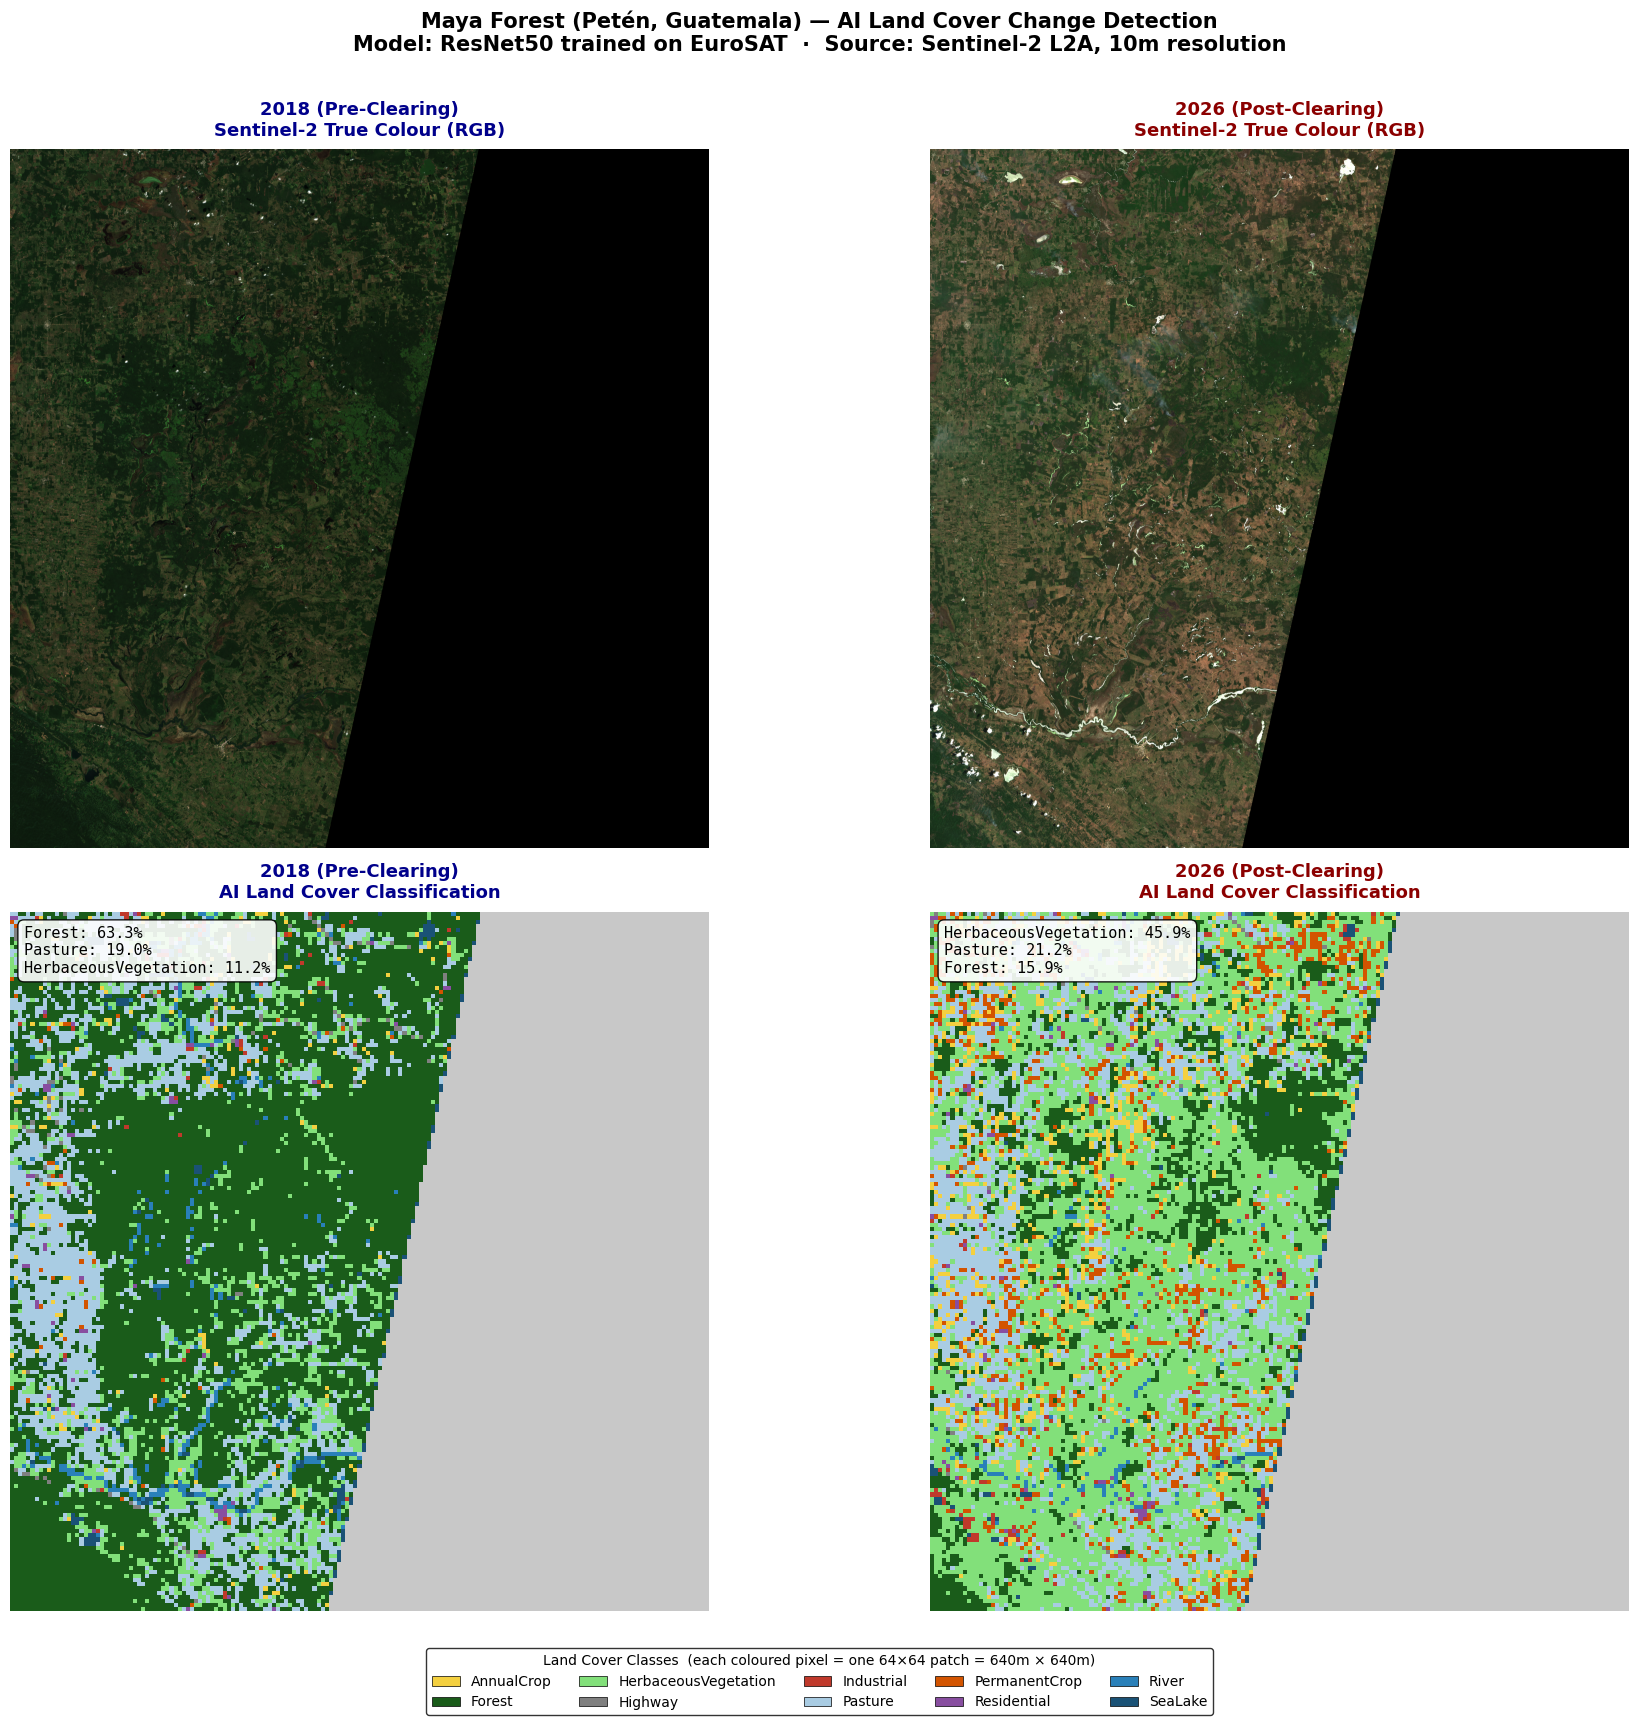

Saved: maya_forest_land_cover_map.png

  CHANGE DETECTION RESULTS
  Forest cover 2018  :  63.2%
  Forest cover 2026  :  15.9%
  Net change         :  -47.4%
  Forest LOST        :  51.9% of study area
  Forest GAINED      :  4.6% of study area (regrowth)

  Lost forest was converted to:
    → AnnualCrop                ██ 7.9%
    → HerbaceousVegetation      █████████████████ 53.9%
    → Highway                    0.4%
    → Industrial                 1.0%
    → Pasture                   ████████ 25.8%
    → PermanentCrop             ██ 8.4%
    → Residential                0.6%
    → River                      0.9%
    → SeaLake                    1.0%


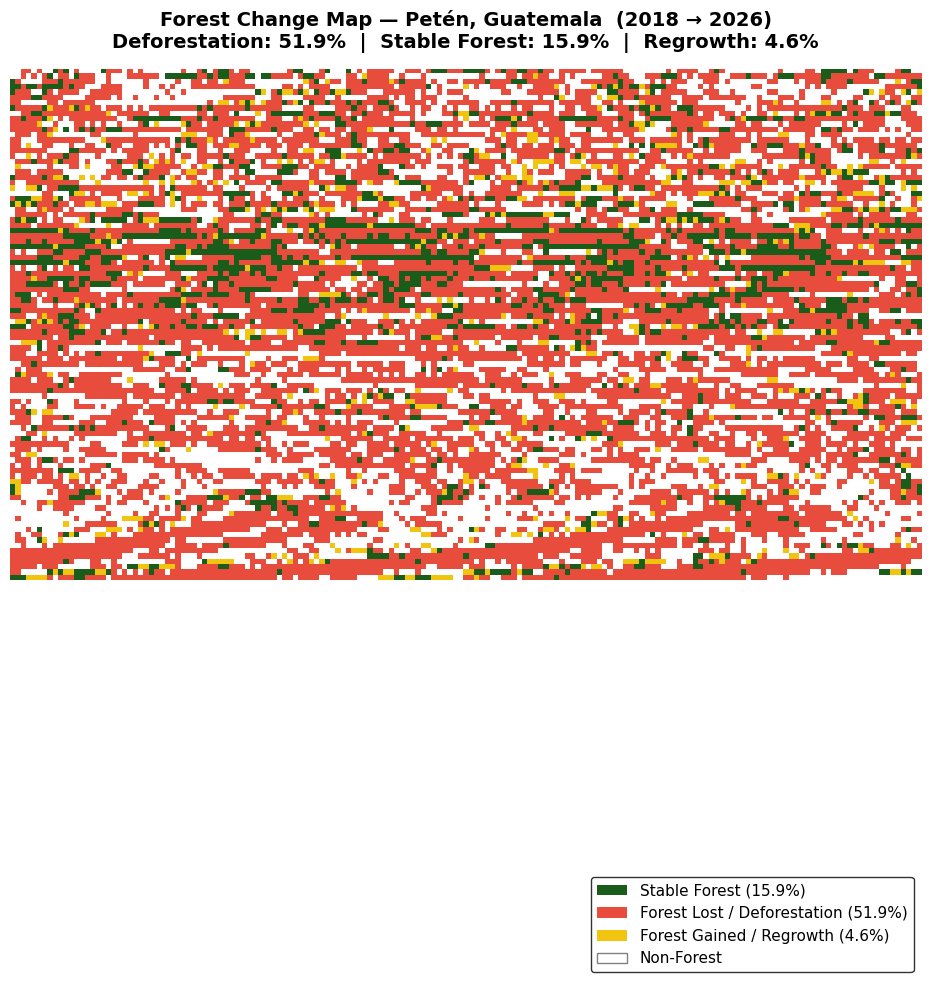

Saved: maya_forest_change_map.png


In [19]:
 def build_color_map(predictions, rows, cols, valid_mask):
    """
    Build colour map, painting no-data (black) patches as grey
    so they don't get misclassified as SeaLake.
    """
    color_map  = np.full((rows, cols, 3), 200, dtype=np.uint8)  # grey default
    pred_idx   = 0

    for pixel_idx in range(rows * cols):
        row = pixel_idx // cols
        col = pixel_idx  % cols

        if valid_mask[pixel_idx]:           # only colour real-data patches
            class_name = CLASS_NAMES[predictions[pred_idx]]
            hex_color  = CLASS_COLORS[class_name].lstrip('#')
            r, g, b    = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
            color_map[row, col] = [r, g, b]
            pred_idx  += 1

    return color_map
 
 
def get_breakdown(predictions):
    """Calculates what % of patches belong to each class."""
    total     = len(predictions)
    breakdown = {}
    for i, name in enumerate(CLASS_NAMES):
        count = int(np.sum(predictions == i))
        if count > 0:
            breakdown[name] = (count / total) * 100
    return dict(sorted(breakdown.items(), key=lambda x: x[1], reverse=True))
 
 
#BUILDING COLOUR MAPS AND BREAKDOWN
 
cmap_2018 = build_color_map(preds_2018, rows_2018, cols_2018, mask_2018)
cmap_2026 = build_color_map(preds_2026, rows_2026, cols_2026, mask_2026)
breakdown_2018 = get_breakdown(preds_2018)
breakdown_2026 = get_breakdown(preds_2026)
 
print("=" * 55)
print(f"  {'2018 (Pre-Clearing)':<26} {'2026 (Post-Clearing)'}")
print("=" * 55)
all_classes = sorted(
    set(list(breakdown_2018.keys()) + list(breakdown_2026.keys())),
    key=lambda x: breakdown_2018.get(x, 0), reverse=True
)
for cls in all_classes:
    p18  = breakdown_2018.get(cls, 0)
    p26  = breakdown_2026.get(cls, 0)
    diff = p26 - p18
    arrow = f"▲{diff:+.1f}%" if diff > 0 else f"▼{diff:+.1f}%"
    print(f"  {cls:<22} {p18:>6.1f}%   →   {p26:>6.1f}%  {arrow}")
print("=" * 55)
 
 
#Plotting satellite images & land cover maps
 
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.patch.set_facecolor('white')
fig.suptitle(
    'Maya Forest (Petén, Guatemala) — AI Land Cover Change Detection\n'
    'Model: ResNet50 trained on EuroSAT  ·  Source: Sentinel-2 L2A, 10m resolution',
    fontsize=15, fontweight='bold', y=1.01
)
 
plot_data = [
    ("2018", img_2018, cmap_2018, breakdown_2018, 'darkblue', "2018 (Pre-Clearing)"),
    ("2026", img_2026, cmap_2026, breakdown_2026, 'darkred',  "2026 (Post-Clearing)"),
]
 
for col_idx, (year, img, cmap, breakdown, color, label) in enumerate(plot_data):
 
    #Top row: original satellite image
    axes[0, col_idx].imshow(img)
    axes[0, col_idx].set_title(
        f"{label}\nSentinel-2 True Colour (RGB)",
        fontsize=13, fontweight='bold', color=color, pad=10
    )
    axes[0, col_idx].axis('off')
 
    #Bottom row: AI land cover map
    axes[1, col_idx].imshow(cmap, interpolation='nearest', aspect='equal')
    axes[1, col_idx].set_title(
        f"{label}\nAI Land Cover Classification",
        fontsize=13, fontweight='bold', color=color, pad=10
    )
    axes[1, col_idx].axis('off')
 
    # Top-3 class text box
    top3_text = '\n'.join([
        f"{cls}: {pct:.1f}%"
        for cls, pct in list(breakdown.items())[:3]
    ])
    axes[1, col_idx].text(
        0.02, 0.98, top3_text,
        transform=axes[1, col_idx].transAxes,
        fontsize=11, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='black', alpha=0.9)
    )
 
#Shared colour legend
present = set(list(breakdown_2018.keys()) + list(breakdown_2026.keys()))
legend_patches = [
    mpatches.Patch(facecolor=CLASS_COLORS[name],
                   edgecolor='black', linewidth=0.5, label=name)
    for name in CLASS_NAMES if name in present
]
fig.legend(
    handles=legend_patches,
    loc='lower center', ncol=5, fontsize=10,
    title='Land Cover Classes  (each coloured pixel = one 64×64 patch = 640m × 640m)',
    title_fontsize=10,
    bbox_to_anchor=(0.5, -0.06),
    frameon=True, edgecolor='black'
)
 
plt.tight_layout()
plt.savefig('maya_forest_land_cover_map.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: maya_forest_land_cover_map.png")
 
 
#Change detection
 
min_len       = min(len(preds_2018), len(preds_2026))
p18           = preds_2018[:min_len]
p26           = preds_2026[:min_len]
total         = min_len
forest_idx    = CLASS_NAMES.index('Forest')
was_forest    = (p18 == forest_idx)
is_forest     = (p26 == forest_idx)
lost_forest   = was_forest & ~is_forest
gained_forest = ~was_forest & is_forest
 
forest_2018_pct = np.sum(was_forest)    / total * 100
forest_2026_pct = np.sum(is_forest)     / total * 100
lost_pct        = np.sum(lost_forest)   / total * 100
gained_pct      = np.sum(gained_forest) / total * 100
 
print("\n" + "=" * 55)
print("  CHANGE DETECTION RESULTS")
print("=" * 55)
print(f"  Forest cover 2018  :  {forest_2018_pct:.1f}%")
print(f"  Forest cover 2026  :  {forest_2026_pct:.1f}%")
print(f"  Net change         :  {forest_2026_pct - forest_2018_pct:+.1f}%")
print(f"  Forest LOST        :  {lost_pct:.1f}% of study area")
print(f"  Forest GAINED      :  {gained_pct:.1f}% of study area (regrowth)")
 
if np.sum(lost_forest) > 0:
    print(f"\n  Lost forest was converted to:")
    lost_dest = p26[lost_forest]
    for i, name in enumerate(CLASS_NAMES):
        count = np.sum(lost_dest == i)
        if count > 0:
            pct = count / np.sum(lost_forest) * 100
            bar = '█' * int(pct / 3)
            print(f"    → {name:<25} {bar} {pct:.1f}%")
print("=" * 55)
 
 
#Forest change map

rows       = min(rows_2018, rows_2026)
cols       = min(cols_2018, cols_2026)
change_map = np.full((rows, cols, 3), 255, dtype=np.uint8)  # white default

for idx in range(min(rows * cols, len(p18), len(p26))):
    row = idx // cols
    col = idx  % cols
    c18 = p18[idx]
    c26 = p26[idx]

    if c18 == forest_idx and c26 == forest_idx:
        change_map[row, col] = [26,  92,  26]    # Dark green indicates stable forest
    elif c18 == forest_idx and c26 != forest_idx:
        change_map[row, col] = [231, 76,  60]    # Red indicates forest lost
    elif c18 != forest_idx and c26 == forest_idx:
        change_map[row, col] = [241, 196, 15]    # Yellow indicates regrowth

fig2, ax = plt.subplots(figsize=(12, 10))
ax.imshow(change_map, interpolation='nearest', aspect='equal')
ax.set_title(
    f'Forest Change Map — Petén, Guatemala  (2018 → 2026)\n'
    f'Deforestation: {lost_pct:.1f}%  |  '
    f'Stable Forest: {forest_2026_pct:.1f}%  |  '
    f'Regrowth: {gained_pct:.1f}%',
    fontsize=14, fontweight='bold', pad=15
)
ax.axis('off')

legend_items = [
    mpatches.Patch(facecolor='#1a5c1a', label=f'Stable Forest ({forest_2026_pct:.1f}%)'),
    mpatches.Patch(facecolor='#e74c3c', label=f'Forest Lost / Deforestation ({lost_pct:.1f}%)'),
    mpatches.Patch(facecolor='#f1c40f', label=f'Forest Gained / Regrowth ({gained_pct:.1f}%)'),
    mpatches.Patch(facecolor='white', edgecolor='grey', label='Non-Forest'),
]
ax.legend(handles=legend_items, loc='lower right',
          fontsize=11, frameon=True, edgecolor='black')

plt.tight_layout()
plt.savefig('maya_forest_change_map.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: maya_forest_change_map.png")

**SUMMARY**

In [25]:
print("\n" + "=" * 55)
print("\t\t\tSUMMARY ")
print("=" * 55)
print(f"  Study Area    : Petén, Guatemala (Maya Biosphere Reserve)")
print(f"  Data Source   : Sentinel-2 L2A, 10m resolution (TCI RGB)")
print(f"  Before Image  : January 8,  2018")
print(f"  After Image   : April 23,   2026")
print(f"  Model         : ResNet50 (transfer learning on EuroSAT)")
print(f"  Patch Size    : {PATCH_SIZE} × {PATCH_SIZE} px  =  640m × 640m per patch")
print(f"  Total Patches : {total:,}")
print()
print("  2018 Land Cover (top 5):")
for cls, pct in list(breakdown_2018.items())[:5]:
    bar = '█' * int(pct / 3)
    print(f"    {cls:<25} {bar} {pct:.1f}%")
print()
print("  2026 Land Cover (top 5):")
for cls, pct in list(breakdown_2026.items())[:5]:
    bar = '█' * int(pct / 3)
    print(f"    {cls:<25} {bar} {pct:.1f}%")
print()
print(f"  KEY FINDING:")
print(f"    Forest cover declined from {forest_2018_pct:.1f}% (2018)")
print(f"    to {forest_2026_pct:.1f}% (2026) — a net loss of")
print(f"    {abs(forest_2026_pct - forest_2018_pct):.1f}% of the total study area.")
print()
print(f"  Figures saved:")
print(f"    maya_forest_land_cover_map.png")
print(f"    maya_forest_change_map.png")
print("=" * 55)


			SUMMARY 
  Study Area    : Petén, Guatemala (Maya Biosphere Reserve)
  Data Source   : Sentinel-2 L2A, 10m resolution (TCI RGB)
  Before Image  : January 8,  2018
  After Image   : April 23,   2026
  Model         : ResNet50 (transfer learning on EuroSAT)
  Patch Size    : 64 × 64 px  =  640m × 640m per patch
  Total Patches : 16,391

  2018 Land Cover (top 5):
    Forest                    █████████████████████ 63.3%
    Pasture                   ██████ 19.0%
    HerbaceousVegetation      ███ 11.2%
    River                      2.2%
    AnnualCrop                 1.3%

  2026 Land Cover (top 5):
    HerbaceousVegetation      ███████████████ 45.9%
    Pasture                   ███████ 21.2%
    Forest                    █████ 15.9%
    PermanentCrop             ██ 7.1%
    AnnualCrop                ██ 6.2%

  KEY FINDING:
    Forest cover declined from 63.2% (2018)
    to 15.9% (2026) — a net loss of
    47.4% of the total study area.

  Figures saved:
    maya_forest_land_cover_m